**Table of contents**<a id='toc0_'></a>    
- [Data Mining Lab 2 - Phase 1](#toc1_)    
  - [Summarized Table of Contents](#toc1_1_)    
  - [Before Starting](#toc1_2_)    
  - [Introduction](#toc1_3_)    
  - [**1. Data Preparation**](#toc1_4_)    
  - [**1.1 Load data**](#toc1_5_)    
        - [**>>> Exercise 1 (Take home):**](#toc1_5_1_1_1_)    
    - [**1.2 Save data**](#toc1_5_2_)    
    - [**1.3 Exploratory data analysis (EDA)**](#toc1_5_3_)    
  - [**2. Feature engineering**](#toc1_6_)    
    - [Using Bag of Words](#toc1_6_1_)    
        - [**>>> Exercise 2 (Take home):**](#toc1_6_1_1_1_)    
  - [**3. Model**](#toc1_7_)    
    - [**3.1 Decision Trees**](#toc1_7_1_)    
  - [**4. Results Evaluation**](#toc1_8_)    
        - [**>>> Exercise 3 (Take home):**](#toc1_8_1_1_1_)    
        - [**>>> Exercise 4 (Take home):**](#toc1_8_1_1_2_)    
        - [**>>> Exercise 5 (Take home):**](#toc1_8_1_1_3_)    
  - [**5. Other things you can try**](#toc1_9_)    
  - [**6. Deep Learning**](#toc1_10_)    
    - [**6.1 Prepare data (X, y)**](#toc1_10_1_)    
    - [**6.2 Deal with categorical label (y)**](#toc1_10_2_)    
    - [**6.3 Build model**](#toc1_10_3_)    
    - [**6.4 Train**](#toc1_10_4_)    
    - [**6.5 Predict on testing data**](#toc1_10_5_)    
        - [**>>> Exercise 6 (Take home):**](#toc1_10_5_1_1_)    
    - [Note](#toc1_10_6_)    
    - [More Information for your reference](#toc1_10_7_)    
  - [**7. Word2Vector**](#toc1_11_)    
    - [**7.1 Prepare training corpus**](#toc1_11_1_)    
    - [**7.2 Training our model**](#toc1_11_2_)    
    - [**7.3 Generating word vector (embeddings)**](#toc1_11_3_)    
    - [**7.4 Using a pre-trained w2v model**](#toc1_11_4_)    
      - [(1) Download model by yourself](#toc1_11_4_1_)    
      - [(2) Using gensim api](#toc1_11_4_2_)    
    - [**7.5 king + woman - man = ?**](#toc1_11_5_)    
        - [**>>> Exercise 7 (Take home):**](#toc1_11_5_1_1_)    
  - [**8. Clustering: k-means**](#toc1_12_)    
      - [Basic concept](#toc1_12_1_1_)    
  - [**9. High-dimension Visualization: t-SNE and UMAP**](#toc1_13_)    
    - [**9.1 Prepare visualizing target**](#toc1_13_1_)    
    - [**9.2 Plot using t-SNE and UMAP (2-dimension)**](#toc1_13_2_)    
        - [**>>> Exercise 8 (Take home):**](#toc1_13_2_1_1_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Data Mining Lab 2 - Phase 1](#toc0_)
In this lab's phase 1 session we will focus on the use of Neural Word Embeddings

## <a id='toc1_1_'></a>[Summarized Table of Contents](#toc0_)
- **Phase 1:**
1. Data preparation
2. Feature engineering
3. Model
4. Results evaluation
5. Other things you could try
6. Deep Learning
7. Word to Vector
8. Clustering
9. High-dimension Visualization


## <a id='toc1_2_'></a>[Before Starting](#toc0_)

**Make sure you have installed all the required libraries and you have the environment ready to run this lab.**
    

---
## <a id='toc1_3_'></a>[Introduction](#toc0_)

**Dataset:** [SemEval 2017 Task](https://competitions.codalab.org/competitions/16380)

**Task:** Classify text data into 4 different emotions using word embeddings and other deep information retrieval approaches.

![pic0.png](./pics/pic0.png)

---
## <a id='toc1_4_'></a>[**1. Data Preparation**](#toc0_)

Before beggining the lab, please make sure to download the [Google News Dataset](https://drive.google.com/file/d/0B7XkCwpI5KDYNlNUTTlSS21pQmM/edit) and place it in a folder named "GoogleNews" in the same directory as this file.

---
## <a id='toc1_5_'></a>[**1.1 Load data**](#toc0_)

We start by loading the csv files into a single pandas dataframe for training and one for testing.

In [5]:
import pandas as pd

### training data
anger_train = pd.read_csv("data/semeval/train/anger-ratings-0to1.train.txt",
                         sep="\t", header=None,names=["id", "text", "emotion", "intensity"])
sadness_train = pd.read_csv("data/semeval/train/sadness-ratings-0to1.train.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
fear_train = pd.read_csv("data/semeval/train/fear-ratings-0to1.train.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
joy_train = pd.read_csv("data/semeval/train/joy-ratings-0to1.train.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])

In [6]:
anger_train.head()

,id,text,emotion,intensity
0,10000,How the fu*k! Who the heck! moved my fridge!.....,anger,0.938
1,10001,So my Indian Uber driver just called someone t...,anger,0.896
2,10002,@DPD_UK I asked for my parcel to be delivered ...,anger,0.896
3,10003,so ef whichever butt wipe pulled the fire alar...,anger,0.896
4,10004,Don't join @BTCare they put the phone down on ...,anger,0.896


In [7]:
# combine 4 sub-dataset
train_df = pd.concat([anger_train, fear_train, joy_train, sadness_train], ignore_index=True)

In [60]:
train_df

,id,text,emotion,intensity,text_tokenized
3237,40410,@ReserveHinata tend to them he's going to get ...,sadness,0.475,"[@, ReserveHinata, tend, to, them, he, 's, goi..."
2200,30196,Loved @Bethenny independence msg on @WendyWill...,joy,0.646,"[Loved, @, Bethenny, independence, msg, on, @,..."
2277,30273,Watching Avatar and wondering why I took so lo...,joy,0.580,"[Watching, Avatar, and, wondering, why, I, too..."
2289,30285,You know what's great about #GBBO ? Contestant...,joy,0.562,"[You, know, what, 's, great, about, #, GBBO, ?..."
338,10338,@fireemblemlord it's the first expac since wra...,anger,0.542,"[@, fireemblemlord, it, 's, the, first, expac,..."
...,...,...,...,...,...
1673,20816,@clairepilkingt2 oh god no that's awful mine d...,fear,0.375,"[@, clairepilkingt2, oh, god, no, that, 's, aw..."
1310,20453,Men cannot even handle the suspicion of a horn...,fear,0.542,"[Men, can, not, even, handle, the, suspicion, ..."
1996,21139,@TayerleLyle awe thank you so much Lyle!! You'...,fear,0.104,"[@, TayerleLyle, awe, thank, you, so, much, Ly..."
2252,30248,There is something v satisfying about opening...,joy,0.602,"[There, is, something, v, satisfying, about, o..."


In [8]:
### testing data
anger_test = pd.read_csv("data/semeval/dev/anger-ratings-0to1.dev.gold.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
sadness_test = pd.read_csv("data/semeval/dev/sadness-ratings-0to1.dev.gold.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
fear_test = pd.read_csv("data/semeval/dev/fear-ratings-0to1.dev.gold.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
joy_test = pd.read_csv("data/semeval/dev/joy-ratings-0to1.dev.gold.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])

# combine 4 sub-dataset
test_df = pd.concat([anger_test, fear_test, joy_test, sadness_test], ignore_index=True)
train_df.head()

,id,text,emotion,intensity
0,10000,How the fu*k! Who the heck! moved my fridge!.....,anger,0.938
1,10001,So my Indian Uber driver just called someone t...,anger,0.896
2,10002,@DPD_UK I asked for my parcel to be delivered ...,anger,0.896
3,10003,so ef whichever butt wipe pulled the fire alar...,anger,0.896
4,10004,Don't join @BTCare they put the phone down on ...,anger,0.896


In [61]:
test_df.head()

,id,text,emotion,intensity
282,40795,watching this uni reveal is so depressing i mi...,sadness,0.667
181,21244,Not the best horror ever but I like that the u...,fear,0.333
302,40815,@AnjiDunlap droop in leggings? Are they wearin...,sadness,0.292
128,21191,"They'll be yo friend, shake your hand, then ki...",fear,0.417
288,40801,@OHSOVICTORIOUS_ @FaZeAdapt We all seen it com...,sadness,0.354


In [ ]:
# shuffle dataset。 
# 使用了 Pandas 的 sample 方法來對 train_df 和 test_df 兩個 DataFrame 進行隨機洗牌（shuffle）
# 隨機重新排序，並將結果重新賦值給 train_df及test_df
train_df = train_df.sample(frac=1)
test_df = test_df.sample(frac=1)

In [62]:
train_df.head()

,id,text,emotion,intensity,text_tokenized
3237,40410,@ReserveHinata tend to them he's going to get ...,sadness,0.475,"[@, ReserveHinata, tend, to, them, he, 's, goi..."
2200,30196,Loved @Bethenny independence msg on @WendyWill...,joy,0.646,"[Loved, @, Bethenny, independence, msg, on, @,..."
2277,30273,Watching Avatar and wondering why I took so lo...,joy,0.580,"[Watching, Avatar, and, wondering, why, I, too..."
2289,30285,You know what's great about #GBBO ? Contestant...,joy,0.562,"[You, know, what, 's, great, about, #, GBBO, ?..."
338,10338,@fireemblemlord it's the first expac since wra...,anger,0.542,"[@, fireemblemlord, it, 's, the, first, expac,..."


In [10]:
print("Shape of Training df: ", train_df.shape)
print("Shape of Testing df: ", test_df.shape)

Shape of Training df:  (3613, 4)
Shape of Testing df:  (347, 4)


---
##### <a id='toc1_5_1_1_1_'></a>[**>>> Exercise 1 (Take home):**](#toc0_)
Plot word frequency for Top 30 words in both train and test dataset. (Hint: refer to DM lab 1)


<Figure size 1200x600 with 0 Axes>

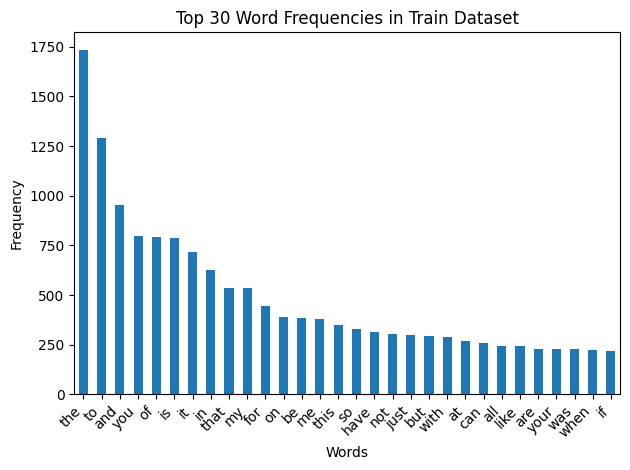

<Figure size 1200x600 with 0 Axes>

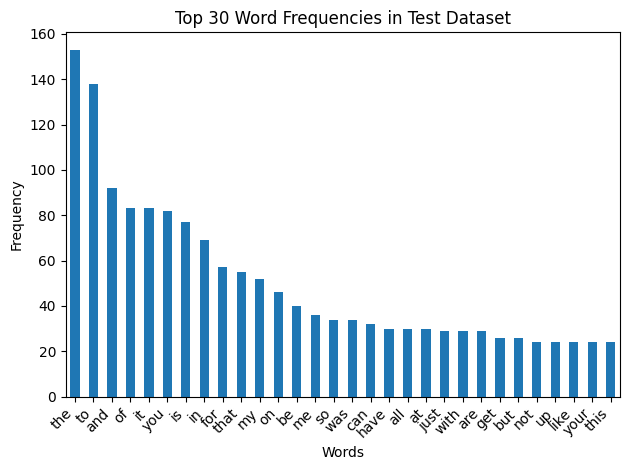

In [81]:
# Answer here
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt

# 函數: 計算並繪製前 30 個詞頻
def plot_top30_word_frequency(df, title):
    # 使用 CountVectorizer 轉換文字為詞頻矩陣
    # 筆記：Feature Extraction with CountVectorizer: converts text into numerical vectors by counting word occurrences
    count_vect = CountVectorizer()
    X_counts = count_vect.fit_transform(df['text'])
    
    # 計算每個詞的總頻率
    terms = count_vect.get_feature_names_out()
    frequencies = np.array(X_counts.sum(axis=0)).ravel()
    
    # 轉為 DataFrame 並排序
    freq_df = pd.DataFrame({'term': terms, 'frequency': frequencies})
    top30 = freq_df.sort_values(by='frequency', ascending=False).head(30)
    
    # 繪製柱狀圖
    plt.figure(figsize=(12, 6))
    top30.plot.bar(x='term', y='frequency', legend=False)
    plt.title(title)
    plt.xlabel('Words')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# 繪製 train_df 的詞頻
plot_top30_word_frequency(train_df, 'Top 30 Word Frequencies in Train Dataset')

# 繪製 test_df 的詞頻
plot_top30_word_frequency(test_df, 'Top 30 Word Frequencies in Test Dataset')


---
### <a id='toc1_5_2_'></a>[**1.2 Save data**](#toc0_)

We will save our data in Pickle format. The pickle module implements binary protocols for serializing and de-serializing a Python object structure.   
  
Some advantages for using pickle structure:  
* Because it stores the attribute type, it's more convenient for cross-platform use.  
* When your data is huge, it could use less space to store also consume less loading time.   

In [12]:
# save to pickle file
train_df.to_pickle("./data/train_df.pkl") 
test_df.to_pickle("./data/test_df.pkl")

In [13]:
import pandas as pd

# load a pickle file
train_df = pd.read_pickle("./data/train_df.pkl")
test_df = pd.read_pickle("./data/test_df.pkl")

For more information: https://reurl.cc/0Dzqx

---
### <a id='toc1_5_3_'></a>[**1.3 Exploratory data analysis (EDA)**](#toc0_)

Again, before getting our hands dirty, we need to explore a little bit and understand the data we're dealing with.

In [ ]:
# group to find distribution
# 了解有多少筆資料屬於不同的情緒分類
train_df.groupby(['emotion']).count()['text']

emotion
anger       857
fear       1147
joy         823
sadness     786
Name: text, dtype: int64

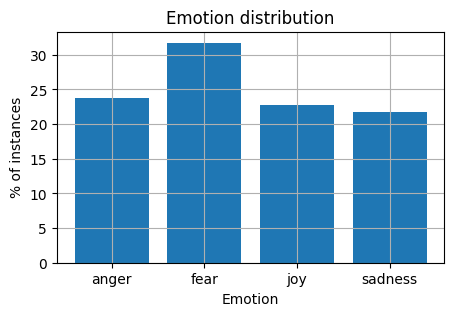

In [67]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# the histogram of the data
labels = train_df['emotion'].unique()     # 取得所有情緒類別
post_total = len(train_df)          # 計算總資料數量
df1 = train_df.groupby(['emotion']).count()['text']  # 計算每個情緒的資料數量
df1 = df1.apply(lambda x: round(x*100/post_total,3)) # 計算每個情緒的百分比

#plot
fig, ax = plt.subplots(figsize=(5,3)) #設定圖表大小
plt.bar(df1.index,df1.values) #繪製長條圖

#arrange
plt.ylabel('% of instances') #設定y軸標籤
plt.xlabel('Emotion') #設定x軸標籤
plt.title('Emotion distribution')
plt.grid(True) #顯示網格線
plt.show() #顯示圖表

---

## <a id='toc1_6_'></a>[**2. Feature engineering**](#toc0_)
### <a id='toc1_6_1_'></a>[Using Bag of Words](#toc0_)
Using scikit-learn ```CountVectorizer``` perform word frequency and use these as features to train a model.  
http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html

In [16]:
from sklearn.feature_extraction.text import CountVectorizer

In [17]:
# build analyzers (bag-of-words)
BOW_vectorizer = CountVectorizer() 

In [ ]:
# 1. Learn a vocabulary dictionary of all tokens in the raw documents.
BOW_vectorizer.fit(train_df['text'])

# 2. Transform documents to document-term matrix.
train_data_BOW_features = BOW_vectorizer.transform(train_df['text'])
test_data_BOW_features = BOW_vectorizer.transform(test_df['text'])

# 筆記：fit() 教的是「詞彙表」 ＃transform(train) 教的是「模型」
# 筆記：為什麼 fit() 不夠？ 只有詞彙表，沒有數字矩陣→ 模型看不懂！

In [68]:
# check the result
train_data_BOW_features
# because it's too big, we cannot see the result. but it has like 3600 something times and 10000 something of sparse matrix.
# 筆記：稀疏矩陣（sparse matrix），大約 3600 筆資料 × 10000 個詞

<3613x10115 sparse matrix of type '<class 'numpy.int64'>'
	with 51467 stored elements in Compressed Sparse Row format>

In [ ]:
type(train_data_BOW_features) 
# 筆記：「告訴我 train_data_BOW_features 是什麼東西？」-> 這是一個稀疏矩陣（sparse matrix），用 CSR 格式儲存

scipy.sparse._csr.csr_matrix

In [ ]:
# add .toarray() to show
train_data_BOW_features.toarray()

# 筆記：.toarray() 把稀疏矩陣轉成一般的 Numpy 陣列（dense matrix），為了教學展示資料使用，大資料不能用一般陣列，會當機

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [22]:
# check the dimension
train_data_BOW_features.shape

(3613, 10115)

In [71]:
# observe some feature names
feature_names = BOW_vectorizer.get_feature_names_out()
feature_names[100:130]

# 筆記：get_feature_names_out() -> 取出詞彙表 所有出現過的詞
#      feature_names[100:110] -> 印出 第100到129個詞

array(['2k17', '2much', '2nd', '30', '300', '301', '30am', '30pm', '30s',
       '31', '32', '320', '339', '34', '340', '342', '349', '36', '37',
       '3abla', '3am', '3amdeadtime', '3d', '3rd', '3x', '3years', '3yr',
       '40', '400', '4000'], dtype=object)

The embedding(把文字變成數字) is done. We can technically feed this into our model. However, depending on the embedding technique you use and your model, your accuracy might not be as high, because:

* curse of dimensionality  (we have 10,115 dimension now)
* some important features are ignored (for example, some models using emoticons yeld better performance than counterparts)

**Ｎote: Common Embedding Types**

| 類型     | 工具              | 特點                                                      |
|:--------|:-----------------:|:----------------------------------------------------------|
| BOW      | CountVectorizer   | Simple, sparse, high-dimensional                          |
| TF-IDF   | TfidfVectorizer   | Considers word importance                                 |
| Word2Vec | gensim            | Semantic similarity (e.g., “king” near “queen”)           |
| BERT     | transformers      | Most powerful, but complex                                |

In [ ]:
# 特徵檢查:「如何確認詞彙表裡有沒有特定詞」
"😂" in feature_names

False

In [72]:
"love" in feature_names

True

Let's try using another tokenizer below.

In [ ]:
import nltk

# build analyzers (bag-of-words)
BOW_500 = CountVectorizer(max_features=500, tokenizer=nltk.word_tokenize) # limit to top 500 frequent words #nltk.word_tokenize

# apply analyzer to training data
BOW_500.fit(train_df['text'])

train_data_BOW_features_500 = BOW_500.transform(train_df['text'])

## check dimension
train_data_BOW_features_500.shape

/Users/parinmac/Library/CloudStorage/Dropbox/精神科_個人資料存檔/博班/就讀-清大/課程/114上-資料探勘與應用Data Mining/DM2025Labs/DM2025-Lab2-Exercise/.venv/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


(3613, 500)

In [26]:
train_data_BOW_features_500.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 2, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [3, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [27]:
# observe some feature names
feature_names_500 = BOW_500.get_feature_names_out()
feature_names_500[100:110]

array(['change', 'cheer', 'cheerful', 'cheerfully', 'cheering', 'cheery',
       'come', 'comes', 'could', 'country'], dtype=object)

In [ ]:
"😂" in feature_names_500
# 筆記：we used nltk.word_tokenize as the tokenizer to better handle emojis and special characters, 
# so that emojis like "😂" are treated as individual tokens and included in the vocabulary.
# 筆記：tokenizer = 「你自己定義的切詞規則」

True

---
##### <a id='toc1_6_1_1_1_'></a>[**>>> Exercise 2 (Take home):**](#toc0_)
Generate an embedding using the TF-IDF vectorizer instead of th BOW one with 1000 features and show the feature names for features [100:110].

In [76]:
# Answer here
# Import TF-IDF Vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Build TF-IDF analyzer with top 1000 frequent words using NLTK tokenizer
tfidf_1000 = TfidfVectorizer(max_features=1000, tokenizer=nltk.word_tokenize)

# Apply analyzer to training data
tfidf_1000.fit(train_df['text'])

train_data_tfidf_features_1000 = tfidf_1000.transform(train_df['text'])

# Check dimension
train_data_tfidf_features_1000.shape


(3613, 1000)

In [77]:
# Observe some feature names
feature_names_1000 = tfidf_1000.get_feature_names_out()
feature_names_1000[100:110]

array(['awful', 'b', 'baby', 'back', 'bad', 'ball', 'balls', 'bb18', 'bc',
       'bday'], dtype=object)

---
## <a id='toc1_7_'></a>[**3. Model**](#toc0_)
### <a id='toc1_7_1_'></a>[**3.1 Decision Trees**](#toc0_)
Using scikit-learn ```DecisionTreeClassifier``` performs word frequency and uses these as features to train a model.  
http://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier

In [83]:
from sklearn.tree import DecisionTreeClassifier

# for a classificaiton problem, you need to provide both training & testing data
X_train = BOW_500.transform(train_df['text'])
y_train = train_df['emotion']

X_test = BOW_500.transform(test_df['text'])
y_test = test_df['emotion']

## take a look at data dimension is a good habit  :)
print('X_train.shape: ', X_train.shape)
print('y_train.shape: ', y_train.shape)
print('X_test.shape: ', X_test.shape)
print('y_test.shape: ', y_test.shape)

# TA： "We are calculating the test dataset based on the train dataset, 
#      so if there is a term that occurred in the test dataset but there is none in the train dataset, 
#      then it will not be in the representation."
# 筆記：我們是用「訓練資料」來建立詞彙表，所以如果某個詞「只出現在測試資料」而「訓練資料完全沒看過」，那這個詞在X_train和X_test中都會變成 0（被忽略）


X_train.shape:  (3613, 500)
y_train.shape:  (3613,)
X_test.shape:  (347, 500)
y_test.shape:  (347,)


In [85]:
## build DecisionTree model
DT_model = DecisionTreeClassifier(random_state=1)

## training!
DT_model = DT_model.fit(X_train, y_train)

## predict!
y_train_pred = DT_model.predict(X_train) # on training data
y_test_pred = DT_model.predict(X_test) # on testing data

## so we get the pred result
y_test_pred[:10] # show first 10 predictions on testing data

array(['sadness', 'fear', 'fear', 'fear', 'sadness', 'fear', 'sadness',
       'sadness', 'fear', 'anger'], dtype=object)

---
## <a id='toc1_8_'></a>[**4. Results Evaluation**](#toc0_)

Now we will check the results of our model's performance

In [ ]:
## accuracy
from sklearn.metrics import accuracy_score

acc_train = accuracy_score(y_true=y_train, y_pred=y_train_pred)
acc_test = accuracy_score(y_true=y_test, y_pred=y_test_pred)

print('training accuracy: {}'.format(round(acc_train, 2)))
print('testing accuracy: {}'.format(round(acc_test, 2)))

# Note: for testing dataset because some words in testing data do not appear in training data, that's why the accuracy is only 0.68

training accuracy: 0.99
testing accuracy: 0.68


In [ ]:
## precision, recall, f1-score,
from sklearn.metrics import classification_report

print(classification_report(y_true=y_test, y_pred=y_test_pred))

# Note: although fears has more samples, but the model cannot predict it well, 
# or like it still have difficulty in predicting the correct level of fear emotion.

              precision    recall  f1-score   support

       anger       0.66      0.68      0.67        84
        fear       0.66      0.69      0.67       110
         joy       0.72      0.71      0.71        79
     sadness       0.70      0.64      0.67        74

    accuracy                           0.68       347
   macro avg       0.68      0.68      0.68       347
weighted avg       0.68      0.68      0.68       347



In [ ]:
# support,測試集中各類別實際數量
# macro avg,每個類別的平均表現（不管數量）
# rweighted avg,每個類別的加權平均（按 support 算）
# accuracy,整體準確率

In [ ]:
## check by confusion matrix # how many correct & incorrect predictions
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true=y_test, y_pred=y_test_pred) 
print(cm)

# it's hard to see becuase we don't know which one is which

[[57 18  6  3]
 [16 76  9  9]
 [ 6  9 56  8]
 [ 7 13  7 47]]


In [35]:
# Funciton for visualizing confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import itertools

def plot_confusion_matrix(cm, classes, title='Confusion matrix',
                          cmap=sns.cubehelix_palette(as_cmap=True)):
    """
    This function is modified from: 
    http://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html
    """
    classes.sort()
    tick_marks = np.arange(len(classes))    
    
    fig, ax = plt.subplots(figsize=(5,5))
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels = classes,
           yticklabels = classes,
           title = title,
           xlabel = 'Predicted label',
           ylabel = 'True label')

    fmt = 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), horizontalalignment="center", color="white" if cm[i, j] > thresh else "black")
    ylim_top = len(classes) - 0.5
    plt.ylim([ylim_top, -.5])
    plt.tight_layout()
    plt.show()

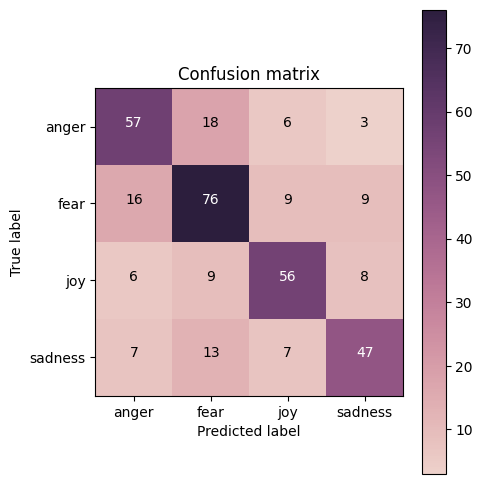

In [36]:
# plot your confusion matrix
my_tags = ['anger', 'fear', 'joy', 'sadness']
plot_confusion_matrix(cm, classes=my_tags, title='Confusion matrix')

---
##### <a id='toc1_8_1_1_1_'></a>[**>>> Exercise 3 (Take home):**](#toc0_)
Can you interpret the results above? What do they mean?

In [ ]:
# Answer here 
# The confusion matrix shows the model’s performance in classifying four emotion categories: anger, fear, joy, and sadness
# Ideally, all values should concentrate on the diagonal, which represents correct predictions. Off-diagonal values 
# indicate misclassifications
# 
# 1. The model achieves around 67–70% accuracy. 
# It performs reasonably well but still confuses some emotion pairs, especially within negative emotions (anger, fear, sadness)
# the model performs fairly well in identifying emotions, particularly “joy,” 
# but it tends to mix negative emotions due to overlapping linguistic expressions
# Future models incorporating contextual and semantic features may improve classification accuracy

---
##### <a id='toc1_8_1_1_2_'></a>[**>>> Exercise 4 (Take home):**](#toc0_)
Build a model using a ```Naive Bayes``` model and train it. What are the testing results? 

*Reference*: https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html

In [87]:
# Answer here
# Build a Naive Bayes model and train it using the same BOW features.

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [88]:
# Prepare data (same as Decision Tree)
X_train = BOW_500.transform(train_df['text'])
y_train = train_df['emotion']

X_test  = BOW_500.transform(test_df['text'])
y_test  = test_df['emotion']

# Check dimensions
print('X_train.shape:', X_train.shape)
print('y_train.shape:', y_train.shape)
print('X_test.shape :', X_test.shape)
print('y_test.shape :', y_test.shape)


X_train.shape: (3613, 500)
y_train.shape: (3613,)
X_test.shape : (347, 500)
y_test.shape : (347,)


In [89]:
# Build the Naive Bayes model
# alpha = 1.0 is Laplace smoothing to avoid zero probabilities
NB_model = MultinomialNB(alpha=1.0)

# Train the model on training data
NB_model.fit(X_train, y_train)


,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [90]:
# Predict on both training and testing sets
y_train_pred = NB_model.predict(X_train)
y_test_pred  = NB_model.predict(X_test)

# Show first 10 predictions on test data
y_test_pred[:10]


array(['joy', 'fear', 'fear', 'fear', 'sadness', 'fear', 'sadness', 'joy',
       'fear', 'anger'], dtype='<U7')

In [91]:
# Evaluate model performance
acc_train = accuracy_score(y_train, y_train_pred)
acc_test  = accuracy_score(y_test,  y_test_pred)

print(f"training accuracy: {acc_train:.2f}")
print(f"testing  accuracy: {acc_test:.2f}")


training accuracy: 0.79
testing  accuracy: 0.70


In [92]:
# Show detailed classification results
print("Classification report on test data:")
print(classification_report(y_test, y_test_pred, digits=2))


Classification report on test data:
              precision    recall  f1-score   support

       anger       0.63      0.65      0.64        84
        fear       0.73      0.77      0.75       110
         joy       0.78      0.71      0.74        79
     sadness       0.64      0.62      0.63        74

    accuracy                           0.70       347
   macro avg       0.70      0.69      0.69       347
weighted avg       0.70      0.70      0.70       347



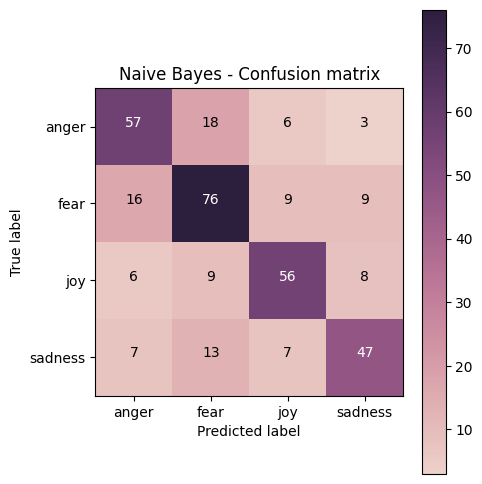

In [93]:
# Visualize confusion matrix using the helper function
my_tags = ['anger', 'fear', 'joy', 'sadness']
plot_confusion_matrix(cm, classes=my_tags, title='Naive Bayes - Confusion matrix')


---
##### <a id='toc1_8_1_1_3_'></a>[**>>> Exercise 5 (Take home):**](#toc0_)

How do the results from the Naive Bayes model and the Decision Tree model compare? How do you interpret these differences? Use the theoretical background covered in class to try and explain these differences.

In [ ]:
# Answer here 
# Both Decision Tree and Naive Bayes reached about the same testing accuracy (Decision Tree=0.68, Naive Bayes=0.70),
# but they “think” in very different ways.
# 
# The Decision Tree makes many if–then rules — it focuses on a few strong words to decide the emotion.
# That works when those words appear often, but people don’t always use the same words to show feelings.
# So even though fear has the most examples, the tree got confused and couldn’t find all the clues.
# 
# Naive Bayes, instead, looks at all the words together and asks,“Across many texts, which emotion usually goes with these words?”
# Because fear texts often include several medium-frequency words like scared, worried, nervous, and afraid,
# it can combine these weak signals, giving much better results for fear (F1 = 0.75).
# 
# For joy, Naive Bayes also did well (F1 ≈ 0.74) because joyful texts often repeat clear positive words such as
# happy, love, great, and amazing — the model easily learns these strong patterns.
# 
# However, anger and sadness went down slightly (F1=0.64 and 0.63).
# These emotions use rarer or more context-dependent words (furious, mad, lonely, broken),
# so the model’s simple word-count logic misses some meaning.
# The Decision Tree can sometimes catch those special word combinations,
# but it also tends to memorize too much from the training data.

# summary:
# Naive Bayes finds general patterns and performs better for emotions like fear and joy that have clear, frequent words.
# Decision Tree can capture special cases for anger and sadness but often overfits.
# That’s why Naive Bayes achieves slightly higher overall accuracy and more stable results.

---

## <a id='toc1_9_'></a>[**5. Other things you can try**](#toc0_)

Thus, there are several things you can try that will affect your results. In order to yield better results, you can experiment by: 
- Trying different features (Feature engineering)e.g Word2Vec, PCA, LDA, FastText, Clustering
- Trying different models
- Analyzing your results and interpret them to improve your feature engineering/model building process
- Iterate through the steps above until finding a satisfying result

Remember that you should also consider the task at hand and the model you'll feed the data to. 

---
## <a id='toc1_10_'></a>[**6. Deep Learning**](#toc0_)

We use [Keras](https://keras.io/) to be our deep learning framework, and follow the [Model (functional API)](https://keras.io/models/model/) to build a Deep Neural Network (DNN) model. Keras runs with Tensorflow in the backend. It's a nice abstraction to start working with NN models. 

Because Deep Learning is a 1-semester course, we can't talk about each detail about it in the lab session. Here, we only provide a simple template about how to build & run a DL model successfully. You can follow this template to design your model.

We will begin by building a fully connected network, which looks like this:

![pic1.png](./pics/pic1.png)

(source: https://github.com/drewnoff/spark-notebook-ml-labs/tree/master/labs/DLFramework)


---
### <a id='toc1_10_1_'></a>[**6.1 Prepare data (X, y)**](#toc0_)

In [40]:
import keras

# standardize name (X, y) 
X_train = BOW_500.transform(train_df['text'])
y_train = train_df['emotion']

X_test = BOW_500.transform(test_df['text'])
y_test = test_df['emotion']

## check dimension is a good habbit 
print('X_train.shape: ', X_train.shape)
print('y_train.shape: ', y_train.shape)
print('X_test.shape: ', X_test.shape)
print('y_test.shape: ', y_test.shape)

X_train.shape:  (3613, 500)
y_train.shape:  (3613,)
X_test.shape:  (347, 500)
y_test.shape:  (347,)


In [41]:
import keras

In [42]:
BOW_500.transform(test_df['text'])

<347x500 sparse matrix of type '<class 'numpy.int64'>'
	with 4103 stored elements in Compressed Sparse Row format>

---
### <a id='toc1_10_2_'></a>[**6.2 Deal with categorical label (y)**](#toc0_)

Rather than put your label `train_df['emotion']` directly into a model, we have to process these categorical (or say nominal) label by ourselves. 

Here, we use the basic method [one-hot encoding](https://en.wikipedia.org/wiki/One-hot) to transform our categorical  labels to numerical ones.


In [43]:
# deal with label (string -> one-hot)
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
label_encoder.fit(y_train)

print('check label: ', label_encoder.classes_)
print('\n## Before convert')
print('y_train[0:4]:\n', y_train[0:4])
print('\ny_train.shape: ', y_train.shape)
print('y_test.shape: ', y_test.shape)

def label_encode(le, labels):
    enc = le.transform(labels)
    return keras.utils.to_categorical(enc)

def label_decode(le, one_hot_label):
    dec = np.argmax(one_hot_label, axis=1)
    return le.inverse_transform(dec)

check label:  ['anger' 'fear' 'joy' 'sadness']

## Before convert
y_train[0:4]:
 3237    sadness
2200        joy
2277        joy
2289        joy
Name: emotion, dtype: object

y_train.shape:  (3613,)
y_test.shape:  (347,)


In [44]:
y_train = label_encode(label_encoder, y_train)
y_test = label_encode(label_encoder, y_test)

print('\n\n## After convert')
print('y_train[0:4]:\n', y_train[0:4])
print('\ny_train.shape: ', y_train.shape)
print('y_test.shape: ', y_test.shape)




## After convert
y_train[0:4]:
 [[0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]]

y_train.shape:  (3613, 4)
y_test.shape:  (347, 4)


---
### <a id='toc1_10_3_'></a>[**6.3 Build model**](#toc0_)

In [45]:
# I/O check
input_shape = X_train.shape[1]
print('input_shape: ', input_shape)

output_shape = len(label_encoder.classes_)
print('output_shape: ', output_shape)

input_shape:  500
output_shape:  4


![pic2.png](./pics/pic2.png)

In [46]:
from keras.models import Model
from keras.layers import Input, Dense
from keras.layers import ReLU, Softmax

# input layer
model_input = Input(shape=(input_shape, ))  # 500
X = model_input

# 1st hidden layer
X_W1 = Dense(units=64)(X)  # 64
H1 = ReLU()(X_W1)

# 2nd hidden layer
H1_W2 = Dense(units=64)(H1)  # 64
H2 = ReLU()(H1_W2)

# output layer
H2_W3 = Dense(units=output_shape)(H2)  # 4
H3 = Softmax()(H2_W3)

model_output = H3

# create model
model = Model(inputs=[model_input], outputs=[model_output])

# loss function & optimizer
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# show model construction
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        32,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Softmax)               │ (None, 4)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,484 (142.52 KB)

 Trainable params: 36,484 (142.52 KB)

 Non-trainable params: 0 (0.00 B)

---
### <a id='toc1_10_4_'></a>[**6.4 Train**](#toc0_)

In [47]:
from keras.callbacks import CSVLogger

csv_logger = CSVLogger('logs/training_log.csv')

# training setting
epochs = 25
batch_size = 32

# training!
history = model.fit(X_train, y_train, 
                    epochs=epochs, 
                    batch_size=batch_size, 
                    callbacks=[csv_logger],
                    validation_data = (X_test, y_test))
print('training finish')

Epoch 1/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3687 - loss: 1.3305 - val_accuracy: 0.4352 - val_loss: 1.2872
Epoch 2/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 930us/step - accuracy: 0.6324 - loss: 1.0035 - val_accuracy: 0.6571 - val_loss: 0.9288
Epoch 3/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 775us/step - accuracy: 0.7957 - loss: 0.5943 - val_accuracy: 0.7378 - val_loss: 0.7479
Epoch 4/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 916us/step - accuracy: 0.8425 - loss: 0.4266 - val_accuracy: 0.6945 - val_loss: 0.7682
Epoch 5/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 953us/step - accuracy: 0.8785 - loss: 0.3362 - val_accuracy: 0.6888 - val_loss: 0.7755
Epoch 6/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 908us/step - accuracy: 0.9045 - loss: 0.2783 - val_accuracy: 0.6801 - val_loss: 0.8342
Epoch 7/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 904us/step - accuracy: 0.9255 - loss: 0.2254 - val_accuracy: 0.6830 - val_loss: 0.8719
Epoch 8/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 890us/step - accuracy: 0.9372 - loss: 0.1924 - va

---
### <a id='toc1_10_5_'></a>[**6.5 Predict on testing data**](#toc0_)

In [48]:
## predict
pred_result = model.predict(X_test, batch_size=128)
pred_result[:5]

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


array([[2.6404991e-06, 4.4193207e-03, 2.1790915e-05, 9.9555612e-01],
       [8.2227589e-06, 9.9999046e-01, 6.5201499e-07, 6.5636590e-07],
       [7.9999822e-01, 1.2007340e-02, 1.6901683e-03, 1.8630436e-01],
       [3.1836460e-06, 9.9994612e-01, 4.6640202e-05, 4.0594214e-06],
       [1.9176317e-05, 9.4328620e-08, 2.2669064e-05, 9.9995810e-01]],
      dtype=float32)

In [49]:
pred_result = label_decode(label_encoder, pred_result)
pred_result[:5]

array(['sadness', 'fear', 'anger', 'fear', 'sadness'], dtype=object)

In [50]:
from sklearn.metrics import accuracy_score

print('testing accuracy: {}'.format(round(accuracy_score(label_decode(label_encoder, y_test), pred_result), 2)))

testing accuracy: 0.66


In [51]:
#Let's take a look at the training log
training_log = pd.DataFrame()
training_log = pd.read_csv("logs/training_log.csv")
training_log

,epoch,accuracy,loss,val_accuracy,val_loss
0,0,0.368669,1.330534,0.435158,1.287194
1,1,0.632438,1.003539,0.657061,0.928806
2,2,0.795738,0.594314,0.737752,0.747910
3,3,0.842513,0.426577,0.694524,0.768175
4,4,0.878494,0.336153,0.688761,0.775508
5,5,0.904512,0.278340,0.680115,0.834244
6,6,0.925547,0.225351,0.682997,0.871852
7,7,0.937171,0.192371,0.677233,0.939682
8,8,0.950733,0.160837,0.685879,0.969643
9,9,0.958760,0.141036,0.680115,1.056742


---
##### <a id='toc1_10_5_1_1_'></a>[**>>> Exercise 6 (Take home):**](#toc0_)

Plot the Training and Validation Accuracy and Loss (different plots), just like the images below.(Note: the pictures below are an example from a different model). How to interpret the graphs you got? How are they related to the concept of overfitting/underfitting covered in class?

![pic3.png](./pics/pic3.png)  ![pic4.png](./pics/pic4.png)


In [52]:
# Answer here


---

### <a id='toc1_10_6_'></a>[Note](#toc0_)

If you don't have a GPU (level is higher than GTX 1060) or you are not good at setting lots of things about computer, we recommend you to use the [kaggle kernel](https://www.kaggle.com/kernels) to do deep learning model training. They have already installed all the librarys and provided free GPU for you to use.

Note however that you will only be able to run a kernel for 6 hours. After 6 hours of inactivity, your Kaggle kernel will shut down (meaning if your model takes more than 6 hours to train, you can't train it at once).


### <a id='toc1_10_7_'></a>[More Information for your reference](#toc0_)

* Keras document: https://keras.io/
* Keras GitHub example: https://github.com/keras-team/keras/tree/master/examples
* CS229: Machine Learning: http://cs229.stanford.edu/syllabus.html
* Deep Learning cheatsheet: https://stanford.edu/~shervine/teaching/cs-229/cheatsheet-deep-learning
* If you want to try TensorFlow or PyTorch: https://pytorch.org/tutorials/
https://www.tensorflow.org/tutorials/quickstart/beginner

---
## <a id='toc1_11_'></a>[**7. Word2Vector**](#toc0_)

We will introduce how to use `gensim` to train your word2vec model and how to load a pre-trained model.

https://radimrehurek.com/gensim/index.html

---
### <a id='toc1_11_1_'></a>[**7.1 Prepare training corpus**](#toc0_)

In [53]:
## check library
import gensim

## ignore warnings
import warnings
warnings.filterwarnings('ignore')

# # if you want to see the training messages, you can use it
# import logging
# logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

## the input type
train_df['text_tokenized'] = train_df['text'].apply(lambda x: nltk.word_tokenize(x))
train_df[['id', 'text', 'text_tokenized']].head()

,id,text,text_tokenized
3237,40410,@ReserveHinata tend to them he's going to get ...,"[@, ReserveHinata, tend, to, them, he, 's, goi..."
2200,30196,Loved @Bethenny independence msg on @WendyWill...,"[Loved, @, Bethenny, independence, msg, on, @,..."
2277,30273,Watching Avatar and wondering why I took so lo...,"[Watching, Avatar, and, wondering, why, I, too..."
2289,30285,You know what's great about #GBBO ? Contestant...,"[You, know, what, 's, great, about, #, GBBO, ?..."
338,10338,@fireemblemlord it's the first expac since wra...,"[@, fireemblemlord, it, 's, the, first, expac,..."


In [54]:
## create the training corpus
training_corpus = train_df['text_tokenized'].values
training_corpus[:3]

array([list(['@', 'ReserveHinata', 'tend', 'to', 'them', 'he', "'s", 'going', 'to', 'get', 'infections', '.', '\\n\\nHe', "'s", 'frowning', 'and', 'looking', 'down', 'as', 'he', 'does', 'this', '.', '\\nIt', 'must', 'hurt', 'damn', '.', ']']),
       list(['Loved', '@', 'Bethenny', 'independence', 'msg', 'on', '@', 'WendyWilliams', ',', 'be', 'happy', '&', 'amp', ';', 'fulfilled', 'within', 'yourself', '&', 'amp', ';', 'positivity', 'will', 'flock', 'to', 'you', '#', 'happy', '#', 'independent']),
       list(['Watching', 'Avatar', 'and', 'wondering', 'why', 'I', 'took', 'so', 'long', 'to', 'watch', 'this', '*', 'collapses', 'in', 'a', 'joyous', 'heap', '*'])],
      dtype=object)

---
### <a id='toc1_11_2_'></a>[**7.2 Training our model**](#toc0_)

You can try to train your own model. More details: https://radimrehurek.com/gensim/models/word2vec.html

In [55]:
from gensim.models import Word2Vec

## setting
vector_dim = 100
window_size = 5
min_count = 1
training_epochs = 20

## model
word2vec_model = Word2Vec(sentences=training_corpus, 
                          vector_size=vector_dim, window=window_size, 
                          min_count=min_count, epochs=training_epochs)

![Imgur](https://i.imgur.com/Fca3MCs.png)

---
### <a id='toc1_11_3_'></a>[**7.3 Generating word vector (embeddings)**](#toc0_)

In [56]:
# get the corresponding vector of a word
word_vec = word2vec_model.wv['happy']
word_vec

array([ 0.48609877,  0.3495294 , -0.2184372 ,  0.06389653, -0.01531861,
       -1.1319424 ,  0.66806525,  1.5775453 , -0.41748276, -0.648992  ,
       -0.2720714 , -0.8126977 , -0.3729617 ,  0.7319469 , -0.31882828,
       -0.71158046,  0.24080983, -0.64107203,  0.30073118, -0.6098207 ,
        0.74625105,  1.1348808 ,  0.43779323, -0.01674677,  0.29872316,
        0.10808647, -0.28362727,  0.814278  , -0.15400717,  0.15264563,
        0.41538534, -0.34719896,  0.5818835 , -0.7092463 , -0.1850545 ,
        0.0186028 ,  0.288902  , -0.23506907, -0.08306061, -0.66259843,
        0.00449289,  0.1442474 , -0.6505104 , -0.02174709,  1.2382842 ,
       -0.17292456, -1.1017101 ,  0.3873795 ,  0.24112573,  0.24614091,
       -0.29169333, -0.27325284,  0.05135393, -0.46623614, -0.24241008,
       -0.35189888, -0.00337829, -0.22510813, -0.1597716 ,  0.17160562,
        0.25147498, -0.28164116,  0.2033646 ,  0.07540107, -0.6644041 ,
        0.578866  ,  0.50792426,  0.85855246, -0.97991484,  0.35

In [57]:
# Get the most similar words
word = 'happy'
topn = 10
word2vec_model.wv.most_similar(word, topn=topn)

[('birthday', 0.9170989394187927),
 ('bday', 0.9169757962226868),
 ('smile', 0.9146096110343933),
 ('Be', 0.9105772972106934),
 ('keeping', 0.9063743948936462),
 ('establishment', 0.9060140252113342),
 ('Stephen', 0.9058123826980591),
 ('cry', 0.9029360413551331),
 ('help', 0.9020551443099976),
 ('free', 0.8989942073822021)]

---
### <a id='toc1_11_4_'></a>[**7.4 Using a pre-trained w2v model**](#toc0_)

Instead of training your own model ,you can use a model that has already been trained. Here, we see 2 ways of doing that:


#### <a id='toc1_11_4_1_'></a>[(1) Download model by yourself](#toc0_)

Download from this link: [Kaggle | Google News Vectors](https://www.kaggle.com/datasets/didiersalazar/google-news-vectors)

Copy the data `GoogleNews-vectors-negative300.bin` into the following folder directory: `GoogleNews/`

source: [GoogleNews-vectors-negative300](https://code.google.com/archive/p/word2vec/)

more details: https://radimrehurek.com/gensim/models/keyedvectors.html

In [58]:
from gensim.models import KeyedVectors
# IMPORTANT: Please make sure that you have correctly downloaded the file and put it in the correct directory
## Note: this model is huge, this will take some time ...
model_path = "./GoogleNews/GoogleNews-vectors-negative300.bin"
w2v_google_model = KeyedVectors.load_word2vec_format(model_path, binary=True)
print('load ok')

w2v_google_model.most_similar('happy', topn=10)

load ok


[('glad', 0.7408890724182129),
 ('pleased', 0.6632170677185059),
 ('ecstatic', 0.6626912355422974),
 ('overjoyed', 0.6599286794662476),
 ('thrilled', 0.6514049172401428),
 ('satisfied', 0.6437949538230896),
 ('proud', 0.636042058467865),
 ('delighted', 0.627237856388092),
 ('disappointed', 0.6269949674606323),
 ('excited', 0.6247665286064148)]

#### <a id='toc1_11_4_2_'></a>[(2) Using gensim api](#toc0_)

Other pretrained models are available here: https://github.com/RaRe-Technologies/gensim-data

In [59]:
import gensim.downloader as api

## If you see `SSL: CERTIFICATE_VERIFY_FAILED` error, use this:
import ssl
import urllib.request
ssl._create_default_https_context = ssl._create_unverified_context

glove_twitter_25_model = api.load("glove-twitter-25")
print('load ok')

glove_twitter_25_model.most_similar('happy', topn=10)

[====----------------------------------------------] 9.0% 9.4/104.8MB downloaded

KeyboardInterrupt: 

---
### <a id='toc1_11_5_'></a>[**7.5 king + woman - man = ?**](#toc0_)

Let's run one of the most famous examples for Word2Vec and compute the similarity between these 3 words:

In [ ]:
w2v_google_model.most_similar(positive=['king', 'woman'], negative=['man'])

[('queen', 0.7118193507194519),
 ('monarch', 0.6189674139022827),
 ('princess', 0.5902431011199951),
 ('crown_prince', 0.5499460697174072),
 ('prince', 0.5377321839332581),
 ('kings', 0.5236844420433044),
 ('Queen_Consort', 0.5235945582389832),
 ('queens', 0.5181134343147278),
 ('sultan', 0.5098593831062317),
 ('monarchy', 0.5087411999702454)]

---
##### <a id='toc1_11_5_1_1_'></a>[**>>> Exercise 7 (Take home):**](#toc0_)

Now, we have the word vectors, but our input data is a sequence of words (or say sentence). 
How can we utilize these "word" vectors to represent the sentence data and train our model?


In [ ]:
# Answer here


---
## <a id='toc1_12_'></a>[**8. Clustering: k-means**](#toc0_)

Here we introduce how to use `sklearn` to do the basic **unsupervised learning** approach, k-means.    

more details: http://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html


#### <a id='toc1_12_1_1_'></a>[Basic concept](#toc0_)

![pic5.png](./pics/pic5.png)

(img source: https://towardsdatascience.com/k-means-clustering-identifying-f-r-i-e-n-d-s-in-the-world-of-strangers-695537505d)

In [ ]:
# clustering target
target_list = ['happy', 'fear', 'angry', 'car', 'teacher', 'computer']
print('target words: ', target_list)

# convert to word vector
X = [word2vec_model.wv[word] for word in target_list]

target words:  ['happy', 'fear', 'angry', 'car', 'teacher', 'computer']


In [ ]:
from sklearn.cluster import KMeans

# we have to decide how many cluster (k) we want
k = 2

# k-means model
kmeans_model = KMeans(n_clusters=k)
kmeans_model.fit(X)

# cluster result
cluster_result = kmeans_model.labels_

# show
for i in range(len(target_list)):
    print('word: {} \t cluster: {}'.format(target_list[i], cluster_result[i]))

word: happy 	 cluster: 0
word: fear 	 cluster: 0
word: angry 	 cluster: 0
word: car 	 cluster: 1
word: teacher 	 cluster: 1
word: computer 	 cluster: 1


![pic6.png](./pics/pic6.png)

In [ ]:
#check cluster membership
word = 'student'
word_vec = word2vec_model.wv[word]
kmeans_model.predict([word_vec])

array([1])

In [ ]:
#check cluster membership
word = 'sad'
word_vec = word2vec_model.wv[word]
kmeans_model.predict([word_vec])

array([0])

---
## <a id='toc1_13_'></a>[**9. High-dimension Visualization: t-SNE and UMAP**](#toc0_)

No matter if you use the Bag-of-words, TF-IDF, or Word2Vec, it's very hard to see the embedding result, because the dimension is larger than 3.  

In Lab 1, we already talked about PCA, t-SNE and UMAP. We can use PCA to reduce the dimension of our data, then visualize it. However, if you dig deeper into the result, you'd find it is insufficient.

Our aim will be to create a visualization similar to the one below with t-SNE:

![pic7.png](./pics/pic7.png)

source: https://www.fabian-keller.de/research/high-dimensional-data-visualization 

And also like this for UMAP:

![pic9.png](./pics/pic9.png)

source: https://umap-learn.readthedocs.io/en/latest/auto_examples/plot_mnist_example.html

t-SNE and UMAP reference:  
http://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html 
https://umap-learn.readthedocs.io/en/latest/

---
### <a id='toc1_13_1_'></a>[**9.1 Prepare visualizing target**](#toc0_)

Let's prepare data lists like:
- happy words
- angry words
- data words
- mining words

In [ ]:
word_list = ['happy', 'angry', 'data', 'mining']

topn = 5
happy_words = ['happy'] + [word_ for word_, sim_ in w2v_google_model.most_similar('happy', topn=topn)]
angry_words = ['angry'] + [word_ for word_, sim_ in w2v_google_model.most_similar('angry', topn=topn)]        
data_words = ['data'] + [word_ for word_, sim_ in w2v_google_model.most_similar('data', topn=topn)]        
mining_words = ['mining'] + [word_ for word_, sim_ in w2v_google_model.most_similar('mining', topn=topn)]        

print('happy_words: ', happy_words)
print('angry_words: ', angry_words)
print('data_words: ', data_words)
print('mining_words: ', mining_words)

target_words = happy_words + angry_words + data_words + mining_words
print('\ntarget words: ')
print(target_words)

print('\ncolor list:')
cn = topn + 1
color = ['b'] * cn + ['g'] * cn + ['r'] * cn + ['y'] * cn
print(color)

happy_words:  ['happy', 'glad', 'pleased', 'ecstatic', 'overjoyed', 'thrilled']
angry_words:  ['angry', 'irate', 'enraged', 'indignant', 'incensed', 'annoyed']
data_words:  ['data', 'Data', 'datasets', 'dataset', 'databases', 'statistics']
mining_words:  ['mining', 'Mining', 'mines', 'coal_mining', 'mine', 'miner']

target words: 
['happy', 'glad', 'pleased', 'ecstatic', 'overjoyed', 'thrilled', 'angry', 'irate', 'enraged', 'indignant', 'incensed', 'annoyed', 'data', 'Data', 'datasets', 'dataset', 'databases', 'statistics', 'mining', 'Mining', 'mines', 'coal_mining', 'mine', 'miner']

color list:
['b', 'b', 'b', 'b', 'b', 'b', 'g', 'g', 'g', 'g', 'g', 'g', 'r', 'r', 'r', 'r', 'r', 'r', 'y', 'y', 'y', 'y', 'y', 'y']


---
### <a id='toc1_13_2_'></a>[**9.2 Plot using t-SNE and UMAP (2-dimension)**](#toc0_)

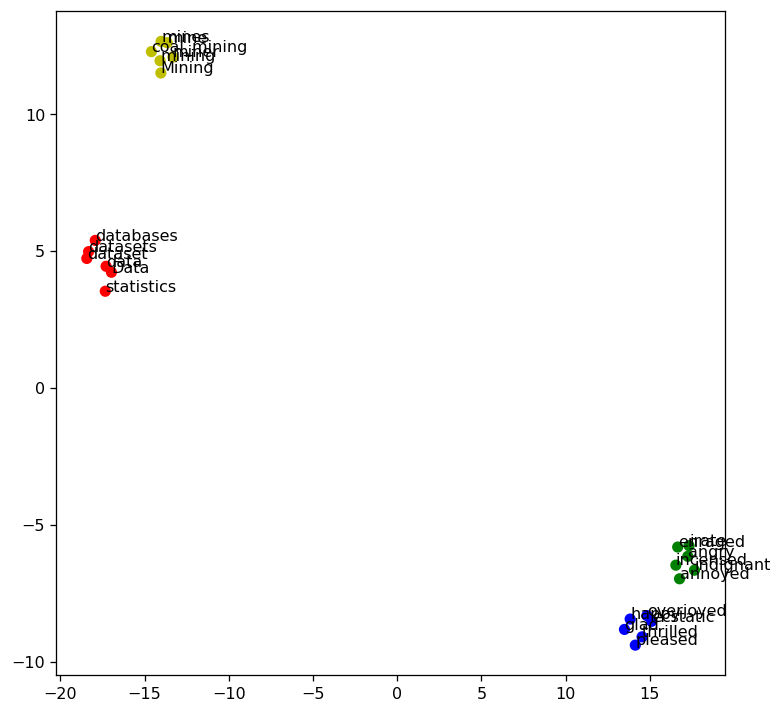

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

## w2v model
model = w2v_google_model

## prepare training word vectors
size = 200
target_size = len(target_words)
all_word = list(model.index_to_key)
word_train = target_words + all_word[:size]
X_train = model[word_train]

## t-SNE model
tsne = TSNE(n_components=2, metric='cosine', random_state=28)

## training
X_tsne = tsne.fit_transform(X_train)

## plot the result
plt.figure(figsize=(7.5, 7.5), dpi=115)
plt.scatter(X_tsne[:target_size, 0], X_tsne[:target_size, 1], c=color)
for label, x, y in zip(target_words, X_tsne[:target_size, 0], X_tsne[:target_size, 1]):
    plt.annotate(label, xy=(x,y), xytext=(0,0),  textcoords='offset points')
plt.show()

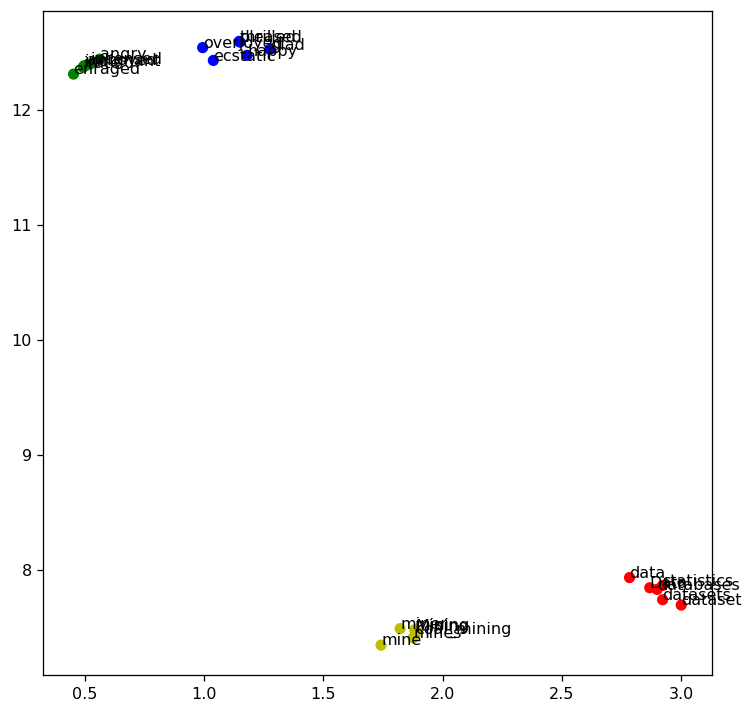

In [ ]:
import matplotlib.pyplot as plt
import umap.umap_ as umap

## w2v model
model = w2v_google_model

## prepare training word vectors
size = 200
target_size = len(target_words)
all_word = list(model.index_to_key)
word_train = target_words + all_word[:size]
X_train = model[word_train]

## UMAP model
umap_model = umap.UMAP(n_components=2, metric='cosine', random_state=28)

## training
X_umap = umap_model.fit_transform(X_train)

## plot the result
plt.figure(figsize=(7.5, 7.5), dpi=115)
plt.scatter(X_umap[:target_size, 0], X_umap[:target_size, 1], c=color)
for label, x, y in zip(target_words, X_umap[:target_size, 0], X_umap[:target_size, 1]):
    plt.annotate(label, xy=(x,y), xytext=(0,0),  textcoords='offset points')
plt.show()


---
##### <a id='toc1_13_2_1_1_'></a>[**>>> Exercise 8 (Take home):**](#toc0_)

Generate a t-SNE and UMAP visualization to show the 15 words most related to the words "angry", "happy", "sad", "fear" (60 words total). Compare the differences between both graphs.

In [ ]:
# Answer here


---